Using device: cuda
[info] Found supervised pair files (X_*, y_*)
[pairs] train=163840 val=20480 test=20480
[norm] u: mean=-4.018e-11 std=1.313 (min=-5.279, max=5.331) | du: mean=7.391e-13 std=0.2342
[data] Cin=9, scalar_dim=2
[epoch 01] train_loss=3.5027e-03 train_rmse=4.5287e-02 | val_loss=3.0002e-03 val_rmse=3.6863e-02
[epoch 02] train_loss=2.1397e-03 train_rmse=3.1674e-02 | val_loss=2.7000e-03 val_rmse=3.3037e-02
[epoch 03] train_loss=1.9268e-03 train_rmse=2.8504e-02 | val_loss=2.3019e-03 val_rmse=2.7007e-02
[epoch 04] train_loss=1.8109e-03 train_rmse=2.6823e-02 | val_loss=2.4617e-03 val_rmse=3.0607e-02
[epoch 05] train_loss=1.7294e-03 train_rmse=2.5893e-02 | val_loss=2.2292e-03 val_rmse=2.7113e-02
[epoch 06] train_loss=1.6666e-03 train_rmse=2.5231e-02 | val_loss=2.3135e-03 val_rmse=3.0436e-02
[epoch 07] train_loss=1.6217e-03 train_rmse=2.4885e-02 | val_loss=2.0187e-03 val_rmse=2.4515e-02
[epoch 08] train_loss=1.5835e-03 train_rmse=2.4516e-02 | val_loss=1.9240e-03 val_rmse=2.5379e-0

/state/partition1/job-3029732/ipykernel_4013943/3894519552.py:564: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


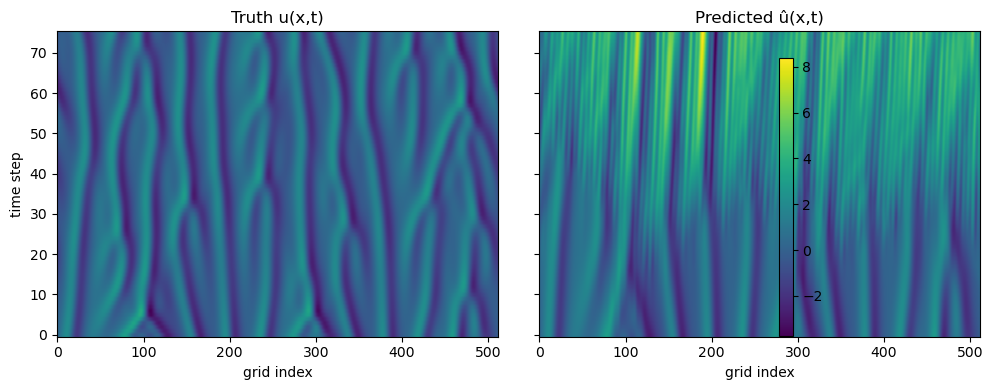

/state/partition1/job-3029732/ipykernel_4013943/3894519552.py:590: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


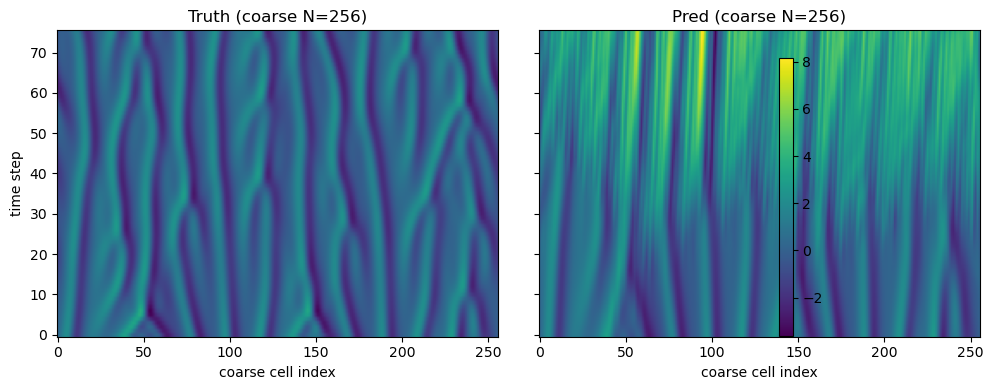

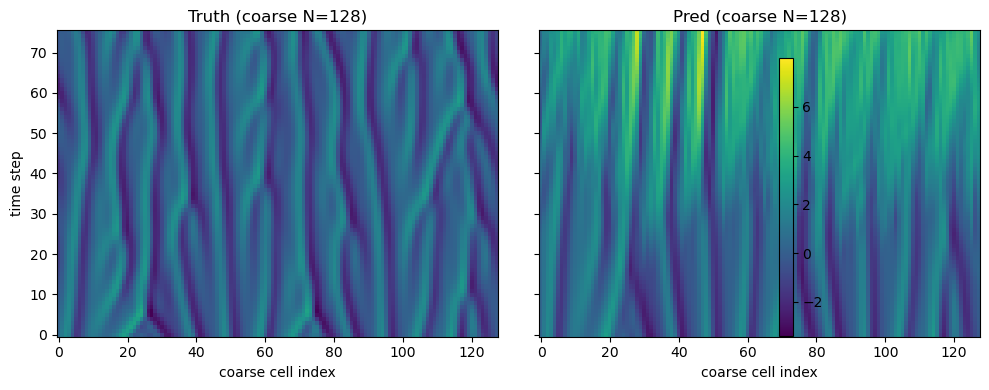

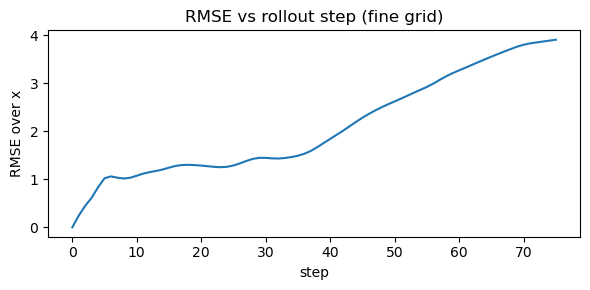

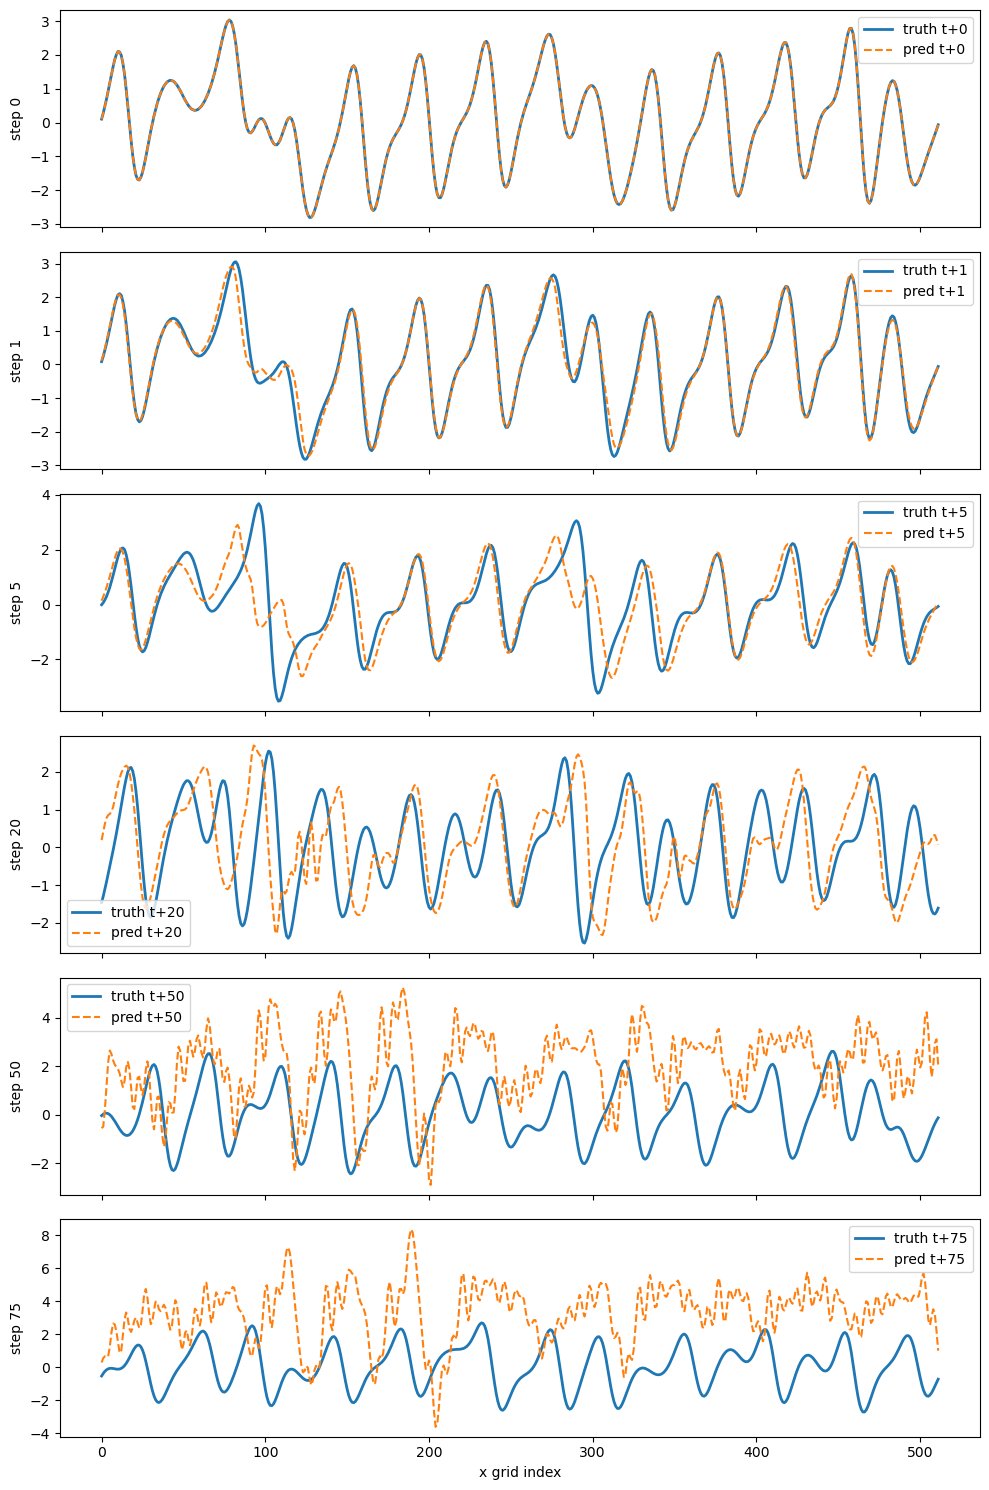

In [1]:
#!/usr/bin/env python
# coding: utf-8

import os
import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ------------------------
# Global config / seeds
# ------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path(".")   # change if your .npy files live elsewhere
FREQS = (1, 2, 4, 8)   # positional encoding frequencies
K_HIST = 1             # we explicitly use only u(t) as input
BATCH_SIZE = 32
EPOCHS = 80
LR = 3e-4
WEIGHT_DECAY = 1e-5
DROPOUT_P = 0.05

# Will be filled after we look at training data
U_MEAN = None
U_STD  = None
DU_MEAN = None
DU_STD  = None
U_MIN = None
U_MAX = None

# Rollout stability hyperparameters (tighter now)
NORM_CLIP       = 3.0   # clamp normalized u to [-NORM_CLIP, NORM_CLIP]
MAX_DELTA_NORM  = 1.5   # clamp normalized Δu to this range
TEMPERATURE     = 0.5   # scale model output in normalized space
JUMP_STD_FACTOR = 1.0   # allowed jump ≈ JUMP_STD_FACTOR * DU_STD
DAMPING_FACTOR  = 0.7   # fraction of excess jump to pull back

# Small spatial smoothing kernel to reduce high-freq noise in rollout
SMOOTH_KERNEL_1D = torch.tensor([0.25, 0.5, 0.25],
                                dtype=torch.float32).view(1, 1, -1)

def smooth_1d(u):
    """
    u: [B, 1, N] (tensor on any device)
    returns smoothed u with same shape
    """
    return torch.nn.functional.conv1d(
        u, SMOOTH_KERNEL_1D.to(u.device), padding=1
    )

# ------------------------
# Data loading helpers
# ------------------------
def load_any_ks_or_supervised(data_dir: Path):
    """
    Try to load either:
      - supervised X/y pairs: X_train.npy, y_train.npy, ...
      - full KS trajectories: ks_data.npy
    Returns a dict with keys:
      mode = 'supervised_pairs' or 'ks_full'
    """
    d = {}

    # Supervised pairs
    if (data_dir / "X_train.npy").exists():
        d["mode"] = "supervised_pairs"
        d["X_train"] = np.load(data_dir / "X_train.npy")
        d["y_train"] = np.load(data_dir / "y_train.npy")
        d["X_val"]   = np.load(data_dir / "X_val.npy")
        d["y_val"]   = np.load(data_dir / "y_val.npy")
        d["X_test"]  = np.load(data_dir / "X_test.npy")
        d["y_test"]  = np.load(data_dir / "y_test.npy")

        # Optional x/t (used for Lx, dt)
        if (data_dir / "ks_spatial_grid.npy").exists():
            d["x"] = np.load(data_dir / "ks_spatial_grid.npy")
        elif (data_dir / "x.npy").exists():
            d["x"] = np.load(data_dir / "x.npy")

        if (data_dir / "ks_time.npy").exists():
            d["t"] = np.load(data_dir / "ks_time.npy")
        elif (data_dir / "t.npy").exists():
            d["t"] = np.load(data_dir / "t.npy")

        print("[info] Found supervised pair files (X_*, y_*)")
        return d

    # Full KS trajectories: ONLY ks_data.npy
    if (data_dir / "ks_data.npy").exists():
        d["mode"] = "ks_full"
        d["ks_data"] = np.load(data_dir / "ks_data.npy")  # [n_traj, T, N]

        if (data_dir / "ks_spatial_grid.npy").exists():
            d["x"] = np.load(data_dir / "ks_spatial_grid.npy")
        elif (data_dir / "x.npy").exists():
            d["x"] = np.load(data_dir / "x.npy")

        if (data_dir / "ks_time.npy").exists():
            d["t"] = np.load(data_dir / "ks_time.npy")
        elif (data_dir / "t.npy").exists():
            d["t"] = np.load(data_dir / "t.npy")

        print("[info] Found ks_data.npy (full KS field)")
        return d

    raise FileNotFoundError("No recognized KS data files found in DATA_DIR.")


def infer_Lx_dt(d):
    """Infer domain length Lx and dt from optional x/t arrays."""
    if "x" in d:
        x = d["x"].astype(np.float32)
        if len(x) >= 2:
            dx = float(x[1] - x[0])
            Lx = dx * len(x)
        else:
            Lx = 2.0 * math.pi
    else:
        Lx = 2.0 * math.pi

    if "t" in d and len(d["t"]) >= 2:
        dt = float(d["t"][1] - d["t"][0])
    else:
        dt = None
    return Lx, dt


def build_pairs_from_ks_full(d, K_hist=1, split=(0.7, 0.15, 0.15)):
    """
    d['ks_data']: [n_traj, T, N].
    We build (u(t), u(t+1)) pairs.
    """
    U = d["ks_data"].astype(np.float32)
    n_traj, T, N = U.shape
    Lx, dt = infer_Lx_dt(d)

    pairs = []
    for k in range(n_traj):
        for t in range(T - 1):
            u_t   = U[k, t]     # [N]
            u_tp1 = U[k, t + 1] # [N]
            pairs.append((u_t, u_tp1))

    rng = np.random.default_rng(SEED)
    rng.shuffle(pairs)
    n_total = len(pairs)
    n_tr = int(split[0] * n_total)
    n_va = int(split[1] * n_total)
    tr_pairs = pairs[:n_tr]
    va_pairs = pairs[n_tr:n_tr + n_va]
    te_pairs = pairs[n_tr + n_va:]
    print(f"[pairs] total={n_total} | train={len(tr_pairs)} "
          f"val={len(va_pairs)} test={len(te_pairs)}")

    return tr_pairs, va_pairs, te_pairs, Lx, dt, U


def build_pairs_from_supervised(d, K_hist=1):
    """
    X_* and y_* have shape [n_pairs, N].
    We'll still treat them as (u(t), u(t+1)).
    """
    Lx, dt = infer_Lx_dt(d)

    def make_pairs(X, Y):
        pairs = []
        for i in range(len(X)):
            u_t   = X[i].astype(np.float32)
            u_tp1 = Y[i].astype(np.float32)
            pairs.append((u_t, u_tp1))
        return pairs

    tr_pairs = make_pairs(d["X_train"], d["y_train"])
    va_pairs = make_pairs(d["X_val"],   d["y_val"])
    te_pairs = make_pairs(d["X_test"],  d["y_test"])

    print(f"[pairs] train={len(tr_pairs)} val={len(va_pairs)} test={len(te_pairs)}")
    return tr_pairs, va_pairs, te_pairs, Lx, dt, None


# ------------------------
# Positional encoding
# ------------------------
def posenc_from_x(x: np.ndarray, freqs):
    """
    x: [N] physical positions.
    Returns [2*len(freqs), N] of sin/cos features.
    """
    x = x.astype(np.float32)
    x_min = float(x.min())
    x_max = float(x.max())
    x_range = max(1e-12, x_max - x_min)
    x01 = (x - x_min) / x_range  # normalize to [0,1]

    n_freqs = len(freqs)
    N = x.shape[0]
    feats = np.zeros((2 * n_freqs, N), dtype=np.float32)

    for i, f in enumerate(freqs):
        angle = 2.0 * math.pi * float(f) * x01
        s = np.sin(angle).astype(np.float32)
        c = np.cos(angle).astype(np.float32)
        feats[2 * i]     = s
        feats[2 * i + 1] = c

    return feats  # [Cpe, N]


# ------------------------
# Dataset with Δu target
# ------------------------
class DeltaUPairsDataset(Dataset):
    def __init__(self, pairs, Lx, dt, freqs=FREQS):
        """
        pairs: list of (u_t, u_tp1), both [N]
        """
        self.pairs = pairs
        self.Lx = float(Lx)
        self.dt = float(dt) if dt is not None else 0.0
        self.freqs = freqs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        u_t, u_tp1 = self.pairs[idx]
        u_t   = u_t.astype(np.float32)
        u_tp1 = u_tp1.astype(np.float32)
        N = u_t.shape[-1]

        # x-grid and dx
        dx = self.Lx / float(N)
        x = (np.arange(N, dtype=np.float32) + 0.5) * dx

        # Positional encoding
        pe = posenc_from_x(x, self.freqs)               # [Cpe, N]

        # Normalize u(t)
        u_t_norm = (u_t - U_MEAN) / U_STD               # [N]

        # Δu(t) = u(t+1) - u(t)
        du = u_tp1 - u_t                                # [N]
        du_norm = (du - DU_MEAN) / DU_STD               # [N]

        # Input profiles: [1 + Cpe, N]
        profiles = np.concatenate([u_t_norm[None, :], pe], axis=0)

        # Scalars = [Lx, dt]
        scalars = np.array([self.Lx, self.dt], dtype=np.float32)

        width = np.full(N, dx, dtype=np.float32)        # area weights
        mask  = np.ones(N, dtype=bool)

        return {
            "profiles": torch.from_numpy(profiles),          # [Cin, N]
            "target":   torch.from_numpy(du_norm[None, :]),  # [1, N]
            "u_t":      torch.from_numpy(u_t[None, :]),      # [1, N]
            "u_tp1":    torch.from_numpy(u_tp1[None, :]),    # [1, N]
            "x":        torch.from_numpy(x),
            "width":    torch.from_numpy(width),
            "mask":     torch.from_numpy(mask),
            "scalars":  torch.from_numpy(scalars),
        }


# ------------------------
# Model: Grid-agnostic 1D conv + scalar conditioning
# ------------------------
class ResidualDilated1D(nn.Module):
    def __init__(self, channels: int, dilation: int, dropout: float = 0.0):
        super().__init__()
        padding = dilation
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3,
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.act1 = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout)

        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3,
                               padding=1, dilation=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.act2 = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: [B, C, L]
        y = self.conv1(x)
        y = self.bn1(y)
        y = self.act1(y)
        y = self.dropout(y)

        y = self.conv2(y)
        y = self.bn2(y)
        y = self.dropout(y)

        y = y + x
        y = self.act2(y)
        return y


class GridAgnostic1D(nn.Module):
    def __init__(self, cin: int, scalar_dim: int = 2,
                 base_channels: int = 64, dilations=(1, 2, 4, 8),
                 dropout: float = 0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(cin, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
        )
        self.blocks = nn.ModuleList(
            [ResidualDilated1D(base_channels, d, dropout=dropout) for d in dilations]
        )
        self.scalar_mlp = nn.Sequential(
            nn.Linear(scalar_dim, base_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(base_channels, base_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
        )
        self.head = nn.Sequential(
            nn.Conv1d(base_channels + base_channels // 2, base_channels, kernel_size=1),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Conv1d(base_channels, 1, kernel_size=1),
        )

    def forward(self, profiles, scalars):
        """
        profiles: [B, Cin, L]
        scalars:  [B, S]
        returns: Δu_norm_pred: [B, 1, L]
        """
        h = self.stem(profiles)            # [B, C, L]
        for blk in self.blocks:
            h = blk(h)                     # [B, C, L]

        s_vec = self.scalar_mlp(scalars)   # [B, C//2]
        s = s_vec.unsqueeze(-1)            # [B, C//2, 1]
        s = s.expand(-1, -1, h.shape[-1])  # [B, C//2, L]

        h_cat = torch.cat([h, s], dim=1)   # [B, C + C//2, L]
        out = self.head(h_cat)             # [B, 1, L]
        return out


# ------------------------
# Loss / metrics
# ------------------------
def masked_weighted_mse(pred, target, mask, width):
    """
    pred, target: [B, 1, N]
    mask: [B, N] (bool)
    width: [B, N]
    """
    mask = mask.unsqueeze(1)          # [B, 1, N]
    width = width.unsqueeze(1)        # [B, 1, N]
    diff2 = (pred - target) ** 2
    diff2 = diff2 * mask * width
    num = diff2.sum()
    den = (width * mask).sum() + 1e-8
    return num / den


def masked_rmse(pred, target, mask, width):
    """
    RMSE over u(t+1) fields.
    """
    mask = mask.unsqueeze(1)
    width = width.unsqueeze(1)
    diff2 = (pred - target) ** 2 * mask * width
    num = diff2.sum(dim=(1, 2))
    den = (width * mask).sum(dim=(1, 2)) + 1e-8
    rmse_per_sample = torch.sqrt(num / den)   # [B]
    return rmse_per_sample.mean().item()


# ------------------------
# Training loop
# ------------------------
def one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_rmse = 0.0
    n_batches = 0

    for batch in loader:
        profiles = batch["profiles"].to(DEVICE)        # [B, Cin, N]
        target_norm = batch["target"].to(DEVICE)       # [B, 1, N] Δu_norm
        u_t_phys = batch["u_t"].to(DEVICE)             # [B, 1, N]
        u_tp1_phys = batch["u_tp1"].to(DEVICE)         # [B, 1, N]
        scalars = batch["scalars"].to(DEVICE)          # [B, 2]
        mask = batch["mask"].to(DEVICE)                # [B, N]
        width = batch["width"].to(DEVICE)              # [B, N]

        if is_train:
            optimizer.zero_grad()

        # Model: Δu_norm_pred
        du_pred_norm = model(profiles, scalars)        # [B, 1, N]

        # Convert Δu back to physical units
        du_pred_phys = du_pred_norm * DU_STD + DU_MEAN
        du_tgt_phys  = target_norm * DU_STD + DU_MEAN

        # u(t+1) = u(t) + Δu(t)
        u_pred_next = u_t_phys + du_pred_phys          # [B, 1, N]
        u_tgt_next = u_tp1_phys

        loss = masked_weighted_mse(du_pred_phys, du_tgt_phys, mask, width)

        if is_train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        rmse = masked_rmse(u_pred_next, u_tgt_next, mask, width)

        total_loss += loss.item()
        total_rmse += rmse
        n_batches += 1

    return total_loss / max(1, n_batches), total_rmse / max(1, n_batches)


# ------------------------
# Rollout + plots (fine + coarse) – STABLE VERSION
# ------------------------
def rollout_from_trajectory(model, U_traj, Lx, dt,
                            traj_id=0, T0=10, steps=200,
                            coarse_factors=(2, 4)):
    """
    U_traj: [n_traj, T, N] or [T, N] physical u(x,t)
    """
    model.eval()
    U_traj = U_traj.astype(np.float32)

    if U_traj.ndim == 2:
        U_traj = U_traj[None, ...]  # -> [1, T, N]

    n_traj, T_total, N = U_traj.shape
    assert 0 <= traj_id < n_traj

    steps = min(steps, T_total - T0 - 1)
    u_truth = U_traj[traj_id]  # [T, N]

    dx = Lx / float(N)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe_np = posenc_from_x(x, FREQS)       # [Cpe, N]
    pe = torch.from_numpy(pe_np[None]).to(DEVICE)  # [1, Cpe, N]
    scalars = torch.tensor([[Lx, dt if dt is not None else 0.0]],
                           dtype=torch.float32, device=DEVICE)

    # Initial u(t0) in physical units
    u_t_phys = torch.from_numpy(u_truth[T0][None, None, :]).to(DEVICE)  # [1, 1, N]

    preds = [u_t_phys.squeeze(0).squeeze(0).cpu().numpy()]
    truth = [u_truth[T0]]

    # Running stats for adaptive normalization
    running_mean = float(u_t_phys.mean().item())
    running_std = float(u_t_phys.std().item() + 1e-6)

    with torch.no_grad():
        for s in range(steps):
            # --- 1) Adaptive normalization for input u(t) ---
            alpha = 0.7  # weight for global stats vs running stats
            norm_mean = alpha * U_MEAN + (1.0 - alpha) * running_mean
            norm_std = alpha * U_STD + (1.0 - alpha) * running_std
            norm_std = max(norm_std, 1e-6)

            norm_mean_t = torch.tensor(norm_mean, device=DEVICE, dtype=u_t_phys.dtype)
            norm_std_t  = torch.tensor(norm_std,  device=DEVICE, dtype=u_t_phys.dtype)

            u_t_norm = (u_t_phys - norm_mean_t) / norm_std_t         # [1, 1, N]
            u_t_norm = torch.clamp(u_t_norm, -NORM_CLIP, NORM_CLIP)  # avoid crazy inputs

            profiles = torch.cat([u_t_norm, pe], dim=1)  # [1, 1+Cpe, N]

            # --- 2) Model prediction in normalized Δu space with temperature + clipping ---
            du_pred_norm = model(profiles, scalars)  # [1, 1, N]
            du_pred_norm = du_pred_norm * TEMPERATURE
            du_pred_norm = torch.clamp(du_pred_norm,
                                       -MAX_DELTA_NORM, MAX_DELTA_NORM)

            # Denormalize Δu
            du_pred_phys = du_pred_norm * DU_STD + DU_MEAN  # [1, 1, N]

            # --- 3) New state in physical units ---
            u_next = u_t_phys + du_pred_phys  # [1, 1, N]

            # Light spatial smoothing to suppress grid-scale noise
            u_next = smooth_1d(u_next)

            # Guard against NaNs / infs
            if not torch.isfinite(u_next).all():
                print(f"[rollout] Non-finite values at step {s}, resetting to previous state.")
                u_next = u_t_phys.clone()

            # --- 4) Update running stats from prediction ---
            running_mean = float(u_next.mean().item())
            running_std = float(u_next.std().item() + 1e-6)

            # --- 5) Adaptive clipping in physical space based on training range ---
            adaptive_min = min(U_MIN, running_mean - 3.5 * running_std)
            adaptive_max = max(U_MAX, running_mean + 3.5 * running_std)

            adaptive_min_t = torch.tensor(adaptive_min, device=DEVICE, dtype=u_next.dtype)
            adaptive_max_t = torch.tensor(adaptive_max, device=DEVICE, dtype=u_next.dtype)
            u_next = torch.clamp(u_next, adaptive_min_t, adaptive_max_t)

            # --- 6) Dampen very large per-step jumps ---
            diff = torch.abs(u_next - u_t_phys)  # [1, 1, N]
            max_allowed_diff = JUMP_STD_FACTOR * DU_STD
            mad_t = torch.tensor(max_allowed_diff, device=DEVICE, dtype=u_next.dtype)

            mask_big = diff > mad_t
            if mask_big.any():
                excess = diff - mad_t
                correction = -DAMPING_FACTOR * excess * torch.sign(u_next - u_t_phys)
                u_next = u_next + correction * mask_big

            # --- 7) Store and iterate ---
            preds.append(u_next.squeeze(0).squeeze(0).cpu().numpy())
            truth.append(u_truth[T0 + s + 1])

            u_t_phys = u_next

    preds = np.stack(preds, axis=0)   # [S+1, N]
    truth = np.stack(truth, axis=0)   # [S+1, N]
    S = preds.shape[0] - 1

    # Heatmaps (fine grid) with shared color scale
    vmin = min(truth.min(), preds.min())
    vmax = max(truth.max(), preds.max())

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    im0 = ax[0].imshow(truth, aspect="auto", origin="lower",
                       vmin=vmin, vmax=vmax, cmap="viridis")
    ax[0].set_title("Truth u(x,t)")
    im1 = ax[1].imshow(preds, aspect="auto", origin="lower",
                       vmin=vmin, vmax=vmax, cmap="viridis")
    ax[1].set_title("Predicted û(x,t)")
    fig.colorbar(im0, ax=ax, shrink=0.9)
    for a in ax:
        a.set_xlabel("grid index")
    ax[0].set_ylabel("time step")
    plt.tight_layout()
    plt.show()

    # Coarse grids with same color scale in each pair
    for factor in coarse_factors:
        if N % factor != 0:
            print(f"[coarse] skip factor={factor} (N={N} not divisible)")
            continue
        Nx_lo = N // factor
        truth_lo = truth.reshape(S + 1, Nx_lo, factor).mean(axis=-1)
        preds_lo = preds.reshape(S + 1, Nx_lo, factor).mean(axis=-1)

        vmin_lo = min(truth_lo.min(), preds_lo.min())
        vmax_lo = max(truth_lo.max(), preds_lo.max())

        fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
        im0 = ax[0].imshow(truth_lo, aspect="auto", origin="lower",
                           vmin=vmin_lo, vmax=vmax_lo, cmap="viridis")
        ax[0].set_title(f"Truth (coarse N={Nx_lo})")
        im1 = ax[1].imshow(preds_lo, aspect="auto", origin="lower",
                           vmin=vmin_lo, vmax=vmax_lo, cmap="viridis")
        ax[1].set_title(f"Pred (coarse N={Nx_lo})")
        fig.colorbar(im0, ax=ax, shrink=0.9)
        for a in ax:
            a.set_xlabel("coarse cell index")
        ax[0].set_ylabel("time step")
        plt.tight_layout()
        plt.show()

    # RMSE vs step on fine grid
    rmse_steps = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    plt.figure(figsize=(6, 3))
    plt.plot(rmse_steps)
    plt.xlabel("step")
    plt.ylabel("RMSE over x")
    plt.title("RMSE vs rollout step (fine grid)")
    plt.tight_layout()
    plt.show()

    # A few snapshot overlays
    SNAP_STEPS = [0, 1, 5, 20, min(50, S), S]
    steps_to_show = sorted({s for s in SNAP_STEPS if 0 <= s <= S})
    k = len(steps_to_show)
    fig, axes = plt.subplots(k, 1, figsize=(10, 2.5 * k), sharex=True)
    if k == 1:
        axes = [axes]
    for ax, s in zip(axes, steps_to_show):
        ax.plot(truth[s], label=f"truth t+{s}", linewidth=2)
        ax.plot(preds[s], "--", label=f"pred t+{s}")
        ax.legend(loc="best")
        ax.set_ylabel(f"step {s}")
    axes[-1].set_xlabel("x grid index")
    plt.tight_layout()
    plt.show()


# ------------------------
# Main: load data, build datasets, train, test
# ------------------------
data_dict = load_any_ks_or_supervised(DATA_DIR)

if data_dict["mode"] == "ks_full":
    tr_pairs, va_pairs, te_pairs, Lx, dt, U_traj_train = build_pairs_from_ks_full(
        data_dict, K_HIST
    )
else:
    tr_pairs, va_pairs, te_pairs, Lx, dt, U_traj_train = build_pairs_from_supervised(
        data_dict, K_HIST
    )

# Compute normalization stats from training set (for u and Δu)
Xtr_all = np.stack([p[0] for p in tr_pairs], axis=0)  # [n_tr, N]
Ytr_all = np.stack([p[1] for p in tr_pairs], axis=0)  # [n_tr, N]
DU_all = Ytr_all - Xtr_all

U_MEAN = float(Xtr_all.mean())
U_STD  = float(Xtr_all.std() + 1e-8)
DU_MEAN = float(DU_all.mean())
DU_STD  = float(DU_all.std() + 1e-8)
U_MIN = float(Xtr_all.min())
U_MAX = float(Xtr_all.max())
print(
    f"[norm] u: mean={U_MEAN:.4g} std={U_STD:.4g} "
    f"(min={U_MIN:.4g}, max={U_MAX:.4g}) | "
    f"du: mean={DU_MEAN:.4g} std={DU_STD:.4g}"
)

# Build datasets / loaders
train_ds = DeltaUPairsDataset(tr_pairs, Lx=Lx, dt=dt, freqs=FREQS)
val_ds   = DeltaUPairsDataset(va_pairs, Lx=Lx, dt=dt, freqs=FREQS)
test_ds  = DeltaUPairsDataset(te_pairs, Lx=Lx, dt=dt, freqs=FREQS)

Cin = train_ds[0]["profiles"].shape[0]
S_dim = train_ds[0]["scalars"].shape[0]
print(f"[data] Cin={Cin}, scalar_dim={S_dim}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Model / optimizer (AdamW with weight decay)
model = GridAgnostic1D(cin=Cin, scalar_dim=S_dim, dropout=DROPOUT_P).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Learning-rate scheduler: reduce on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

# Train
best_val = float("inf")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_rmse = one_epoch(model, train_loader, optimizer=optimizer)
    va_loss, va_rmse = one_epoch(model, val_loader, optimizer=None)
    scheduler.step(va_loss)

    print(f"[epoch {epoch:02d}] "
          f"train_loss={tr_loss:.4e} train_rmse={tr_rmse:.4e} | "
          f"val_loss={va_loss:.4e} val_rmse={va_rmse:.4e}")

    if va_loss < best_val:
        best_val = va_loss
        torch.save(model.state_dict(), "best_grid_agnostic_du.pt")

# Load best and evaluate on test
model.load_state_dict(torch.load("best_grid_agnostic_du.pt",
                                 map_location=DEVICE))
test_loss, test_rmse = one_epoch(model, test_loader, optimizer=None)
print(f"[test] loss={test_loss:.4e} rmse={test_rmse:.4e}")

# Baseline: copy u(t) -> u(t+1) RMSE for comparison
with torch.no_grad():
    copy_rmse = 0.0
    nb = 0
    for batch in test_loader:
        u_t = batch["u_t"]
        u_tp1 = batch["u_tp1"]
        mask = batch["mask"]
        width = batch["width"]
        copy_rmse += masked_rmse(u_t, u_tp1, mask, width)
        nb += 1
    copy_rmse /= max(1, nb)
print(f"[baseline] copy u(t)->u(t+1) RMSE = {copy_rmse:.4e}")

# ------------------------
# Long rollout + plots (ONLY ks_data.npy or fallback to ks_full training data)
# ------------------------
U_rollout = None
Lx_rollout, dt_rollout = None, None
t_roll = None  # for choosing t≈3

# First try ks_data.npy explicitly
if (DATA_DIR / "ks_data.npy").exists():
    U_rollout = np.load(DATA_DIR / "ks_data.npy").astype(np.float32)
    if (DATA_DIR / "ks_spatial_grid.npy").exists():
        x_roll = np.load(DATA_DIR / "ks_spatial_grid.npy").astype(np.float32)
    else:
        x_roll = np.load(DATA_DIR / "x.npy").astype(np.float32)
    if (DATA_DIR / "ks_time.npy").exists():
        t_roll = np.load(DATA_DIR / "ks_time.npy").astype(np.float32)
    elif (DATA_DIR / "t.npy").exists():
        t_roll = np.load(DATA_DIR / "t.npy").astype(np.float32)

    dx_roll = float(x_roll[1] - x_roll[0])
    Lx_rollout = dx_roll * len(x_roll)
    if t_roll is not None and len(t_roll) >= 2:
        dt_rollout = float(t_roll[1] - t_roll[0])
    else:
        dt_rollout = dt
    print(f"[rollout] Using ks_data.npy | Lx={Lx_rollout:.3f}, "
          f"dt={dt_rollout:.4f}, shape={U_rollout.shape}")

# If still None, but we trained on ks_full, fall back to that
if U_rollout is None and U_traj_train is not None:
    U_rollout = U_traj_train
    Lx_rollout, dt_rollout = Lx, dt
    print(f"[rollout] Using training ks_data (from ks_full mode) | "
          f"shape={U_rollout.shape}")

if U_rollout is not None:
    if t_roll is not None:
        t_target = 3.0
        T0 = int(np.argmin(np.abs(t_roll - t_target)))
        T0 = max(0, min(T0, U_rollout.shape[-2] - 2))
        print(f"[rollout] start index from time ~{t_target}: "
              f"T0={T0}, t≈{t_roll[T0]:.3f}")
    else:
        T0 = 3
        print(f"[rollout] no time array found; starting from index T0={T0}")

    rollout_from_trajectory(
        model,
        U_traj=U_rollout,
        Lx=Lx_rollout,
        dt=dt_rollout,
        traj_id=0,
        T0=T0,
        steps=200,
        coarse_factors=(2, 4),
    )
else:
    print("[rollout] No KS trajectory found for rollout (only supervised pairs present).")
